# Financial News Data EDA and Cleaning

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Database path
DB_PATH = '../data/database.db'

# Load entire dataset into a pandas DataFrame
connection = sqlite3.connect(DB_PATH)
df = pd.read_sql_query('SELECT * FROM article_table', connection)
connection.close()

print(f"Total articles loaded: {len(df)}")
print(f"\nColumn names: {df.columns.tolist()}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nNull values:\n{df.isnull().sum()}")

Total articles loaded: 47002

Column names: ['ticker', 'article_id', 'source', 'title', 'link', 'content', 'pubdateunix', 'kicker', 'paywalltype', 'body_fetched']

Data types:
ticker            str
article_id      int64
source            str
title             str
link              str
content           str
pubdateunix     int64
kicker            str
paywalltype       str
body_fetched    int64
dtype: object

Null values:
ticker          0
article_id      0
source          0
title           0
link            0
content         0
pubdateunix     0
kicker          0
paywalltype     0
body_fetched    0
dtype: int64


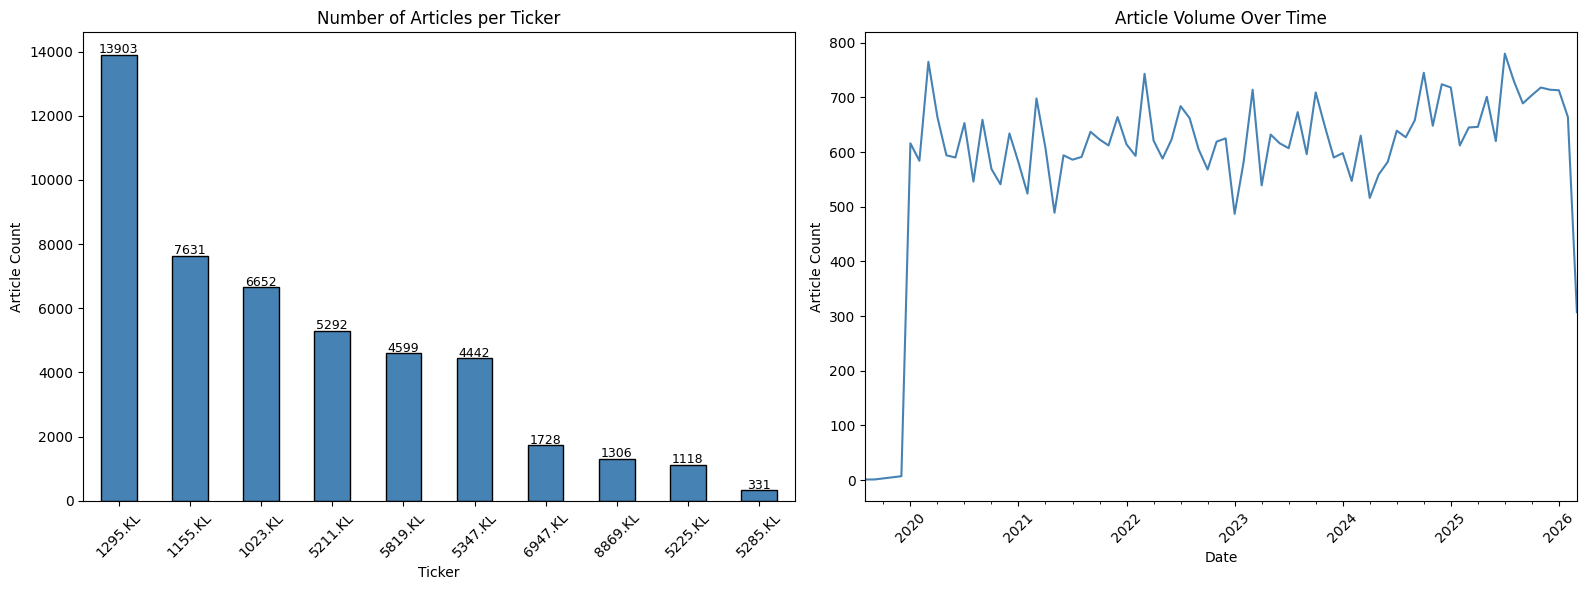


Article counts per ticker:
ticker
1295.KL    13903
1155.KL     7631
1023.KL     6652
5211.KL     5292
5819.KL     4599
5347.KL     4442
6947.KL     1728
8869.KL     1306
5225.KL     1118
5285.KL      331
dtype: int64

Date range: 2019-08-03 23:00:00 to 2026-03-13 07:02:00


In [4]:
# ============================================================
# 1. ARTICLE DISTRIBUTION ACROSS TICKERS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count articles per ticker
ticker_counts = df.groupby('ticker').size().sort_values(ascending=False)

# Bar chart
ticker_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Number of Articles per Ticker')
axes[0].set_xlabel('Ticker')
axes[0].set_ylabel('Article Count')
axes[0].tick_params(axis='x', rotation=45)

# Add count labels on top of each bar
for i, v in enumerate(ticker_counts):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=9)

# ============================================================
# 2. ARTICLE DISTRIBUTION OVER TIME
# ============================================================
# Convert unix timestamp to datetime
df['date'] = pd.to_datetime(df['pubdateunix'], unit='s')
df['year_month'] = df['date'].dt.to_period('M')

# Count articles per month
monthly_counts = df.groupby('year_month').size()
monthly_counts.plot(kind='line', ax=axes[1], color='steelblue')
axes[1].set_title('Article Volume Over Time')
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Article Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nArticle counts per ticker:")
print(ticker_counts)
print(f"\nDate range: {df['date'].min()} to {df['date'].max()}")

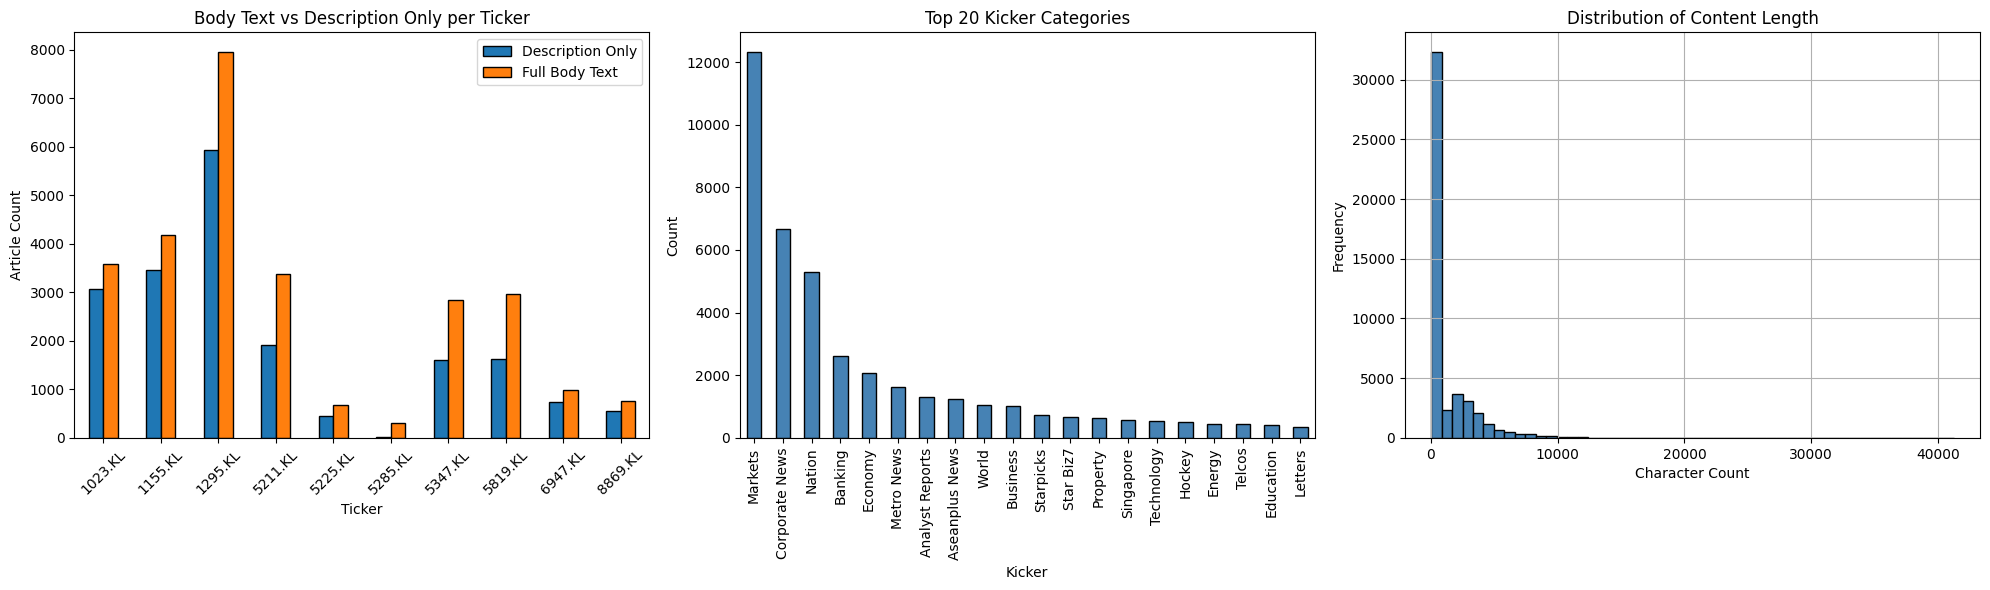

Body text status per ticker:
         Description Only  Full Body Text
ticker                                   
1023.KL              3062            3590
1155.KL              3458            4173
1295.KL              5939            7964
5211.KL              1911            3381
5225.KL               443             675
5285.KL                25             306
5347.KL              1601            2841
5819.KL              1627            2972
6947.KL               747             981
8869.KL               549             757

Content length statistics:
count    47002.000000
mean      1243.550126
std       1901.156302
min         25.000000
25%        199.000000
50%        317.000000
75%       1821.000000
max      41242.000000
Name: content_length, dtype: float64

Top 20 kickers:
kicker
Markets            12331
Corporate News      6658
Nation              5301
Banking             2602
Economy             2056
Metro News          1615
Analyst Reports     1318
Aseanplus News      1250
Wo

In [5]:
# ============================================================
# 3. BODY TEXT VS DESCRIPTION ONLY
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Count body_fetched per ticker
body_status = df.groupby(['ticker', 'body_fetched']).size().unstack(fill_value=0)
body_status.columns = ['Description Only', 'Full Body Text']
body_status.plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title('Body Text vs Description Only per Ticker')
axes[0].set_xlabel('Ticker')
axes[0].set_ylabel('Article Count')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# ============================================================
# 4. KICKER DISTRIBUTION
# ============================================================
kicker_counts = df['kicker'].value_counts().head(20)
kicker_counts.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='black')
axes[1].set_title('Top 20 Kicker Categories')
axes[1].set_xlabel('Kicker')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=90)

# ============================================================
# 5. CONTENT LENGTH DISTRIBUTION
# ============================================================
df['content_length'] = df['content'].str.len()
df['content_length'].hist(bins=50, ax=axes[2], color='steelblue', edgecolor='black')
axes[2].set_title('Distribution of Content Length')
axes[2].set_xlabel('Character Count')
axes[2].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print summaries
print("Body text status per ticker:")
print(body_status)
print(f"\nContent length statistics:")
print(df['content_length'].describe())
print(f"\nTop 20 kickers:")
print(kicker_counts)

Articles with content length under 50 characters:
Count: 5
        ticker   source                                                  title                                           content  content_length  body_fetched
18348  1295.KL  thestar      Asean news headlines as at 9pm on Friday (Jan 26)   Malaysia * Mokhzani Mahathir questioned by MACC              47             1
19094  1295.KL  thestar   Asean News Headlines at 9pm on Tuesday (Dec 6, 2022)           Malaysia: * Anwar: Don’t call me ‘papa’              39             1
19314  1295.KL  thestar  Asean News Headlines as at 9pm on Wednesday (June 15)         Malaysia: * Sibu to host Sarawak Day 2022              41             1
31752  5211.KL  thestar                                   Treasured traditions                         Avante Hotel Avante Hotel              25             1
32005  5211.KL  thestar                                       Sassy nightspots  G-STRING KL No.147, Jalan Petaling, Kuala Lumpur              48  

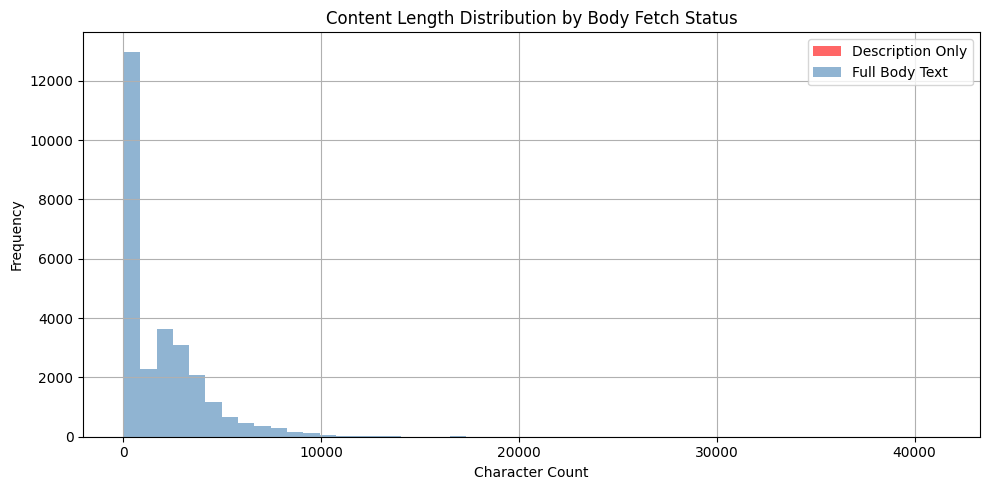

In [6]:
# ============================================================
# 6. INVESTIGATE SUSPICIOUSLY SHORT ARTICLES
# ============================================================
print("Articles with content length under 50 characters:")
short_articles = df[df['content_length'] < 50]
print(f"Count: {len(short_articles)}")
print(short_articles[['ticker', 'source', 'title', 'content', 'content_length', 'body_fetched']].to_string())

# ============================================================
# 7. INVESTIGATE CONTENT LENGTH BY BODY_FETCHED STATUS
# ============================================================
print("\nContent length statistics by body_fetched status:")
print(df.groupby('body_fetched')['content_length'].describe())

# ============================================================
# 8. CONTENT LENGTH DISTRIBUTION SPLIT BY BODY_FETCHED
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))
df[df['body_fetched'] == 0]['content_length'].hist(bins=50, alpha=0.6, label='Description Only', ax=ax, color='red')
df[df['body_fetched'] == 1]['content_length'].hist(bins=50, alpha=0.6, label='Full Body Text', ax=ax, color='steelblue')
ax.set_title('Content Length Distribution by Body Fetch Status')
ax.set_xlabel('Character Count')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ============================================================
# 9. EXAMINE IRRELEVANT KICKER CONTENT
# ============================================================

# Kickers we want to examine before deciding to filter
suspect_kickers = ['Hockey', 'Metro News', 'Letters', 'Aseanplus News', 
                   'Singapore', 'Education', 'World', 'Property', 
                   'Technology', 'Starpicks', 'Star Biz7']

for kicker in suspect_kickers:
    sample = df[df['kicker'] == kicker]['title'].head(3).tolist()
    print(f"\n{kicker}:")
    for title in sample:
        print(f"  - {title}")

# ============================================================
# 10. KICKER DISTRIBUTION FOR BODY_FETCHED = 1 ONLY
# ============================================================
print("\n\nKicker counts for full body text articles only:")
print(df[df['body_fetched'] == 1]['kicker'].value_counts().head(25))


Hockey:
  - Tenaga storm into TNB Cup final after fiery clash with Maybank
  - Tough for depleted Maybank to face Thunderbolts in MHL
  - Indoor adventure for seven, but outdoor concern for Maybank

Metro News:
  - RM14m boost from Maybank to upgrade capacity in two major public hospitals
  - Bank launches parallel CSR events across the world
  - Bamboo fuels future for Temiar villagers in Perak

Letters:
  - A reminder of humanity at the end of a phone line
  - Digital finance is driving a greener future for Malaysia
  - Prey augmentation efforts crucial to saving Malayan tigers from extinction

Aseanplus News:
  - 'Oh dear, it's really hot out there, ' but kudos to the players, they are so cool about it at the Maybank Championship
  - Malaysia's sporting extravaganza - Maybank Championship 2025: An Asean story of sport, culture and purpose
  - 'This win, I will never forget' - LPGA rookie Miyu Yamashita wins LPGA Maybank Championship after three-way playoff

Singapore:
  - Malaysia'

In [8]:
# ============================================================
# 11. DEFINE CLEANING RULES AND CREATE CLEANED DATAFRAME
# ============================================================

# Kickers to remove - sports, opinion letters, generic education content
KICKERS_TO_DROP = ['Hockey', 'Letters', 'Education', 'Star Biz7']

# Minimum content length for full body text articles
# Based on our analysis, full body articles start at 370 chars (25th percentile)
# We use 200 as a conservative cutoff to remove only genuinely useless content
MIN_CONTENT_LENGTH = 200

print("Before cleaning:")
print(f"  Total articles: {len(df)}")
print(f"  Body fetched = 1: {len(df[df['body_fetched'] == 1])}")

# Apply cleaning filters
df_clean = df[
    (df['body_fetched'] == 1) &                          # Full body text only
    (~df['kicker'].isin(KICKERS_TO_DROP)) &              # Remove irrelevant kickers
    (df['content_length'] >= MIN_CONTENT_LENGTH)         # Remove suspiciously short articles
].copy()

# Reset index
df_clean = df_clean.reset_index(drop=True)

print("\nAfter cleaning:")
print(f"  Total articles: {len(df_clean)}")
print(f"  Articles removed: {len(df) - len(df_clean)}")

print("\nArticles per ticker after cleaning:")
print(df_clean.groupby('ticker').size().sort_values(ascending=False))

print("\nKicker distribution after cleaning:")
print(df_clean['kicker'].value_counts())

Before cleaning:
  Total articles: 47002
  Body fetched = 1: 27640

After cleaning:
  Total articles: 26870
  Articles removed: 20132

Articles per ticker after cleaning:
ticker
1295.KL    7656
1155.KL    4108
1023.KL    3538
5211.KL    3149
5819.KL    2941
5347.KL    2784
6947.KL     971
8869.KL     748
5225.KL     669
5285.KL     306
dtype: int64

Kicker distribution after cleaning:
kicker
Markets             6778
Corporate News      4768
Nation              3698
Banking             1373
Economy             1245
                    ... 
Whatsapp               1
Ios                    1
Science                1
Drones                 1
Food For Thought       1
Name: count, Length: 137, dtype: int64


In [9]:
# ============================================================
# 12. EXAMINE AND FILTER RARE KICKERS
# ============================================================

# Show full kicker distribution
kicker_counts_clean = df_clean['kicker'].value_counts()

print("Full kicker distribution:")
print(kicker_counts_clean.to_string())

print(f"\nTotal unique kickers: {len(kicker_counts_clean)}")
print(f"\nKickers appearing fewer than 10 times:")
rare_kickers = kicker_counts_clean[kicker_counts_clean < 10]
print(rare_kickers.to_string())
print(f"\nTotal rare kickers (< 10 articles): {len(rare_kickers)}")
print(f"Total articles in rare kickers: {rare_kickers.sum()}")

Full kicker distribution:
kicker
Markets                    6778
Corporate News             4768
Nation                     3698
Banking                    1373
Economy                    1245
Metro News                 1050
Aseanplus News              717
Starpicks                   680
Analyst Reports             614
World                       527
Singapore                   460
Business                    430
Technology                  289
Property                    268
Telcos                      237
Commodities                 186
Forex                       164
Internet                    161
Construction                158
Indonesia                   144
Energy                      143
Investment                  141
Focus                       140
China                       134
Sabah &amp; Sarawak         131
Thailand                    128
Cybersecurity               111
Vietnam                     104
Insight                      91
Plantations                  90
Stock O

In [10]:
# ============================================================
# 13. FINAL KICKER FILTERING
# ============================================================

# Drop kickers with fewer than 10 articles (too rare to be meaningful)
rare_kicker_names = kicker_counts_clean[kicker_counts_clean < 10].index.tolist()

# Additional irrelevant kickers identified from full distribution review
ADDITIONAL_KICKERS_TO_DROP = [
    'Football', 'Golf', 'Bowling', 'Badminton', 'Community Sports',  # Sports
    'Video Games', 'Style', 'Eating Out', 'Food News', 'Living',      # Lifestyle
    'Family', 'Entertainment', 'Arts', 'True Or Not',                 # Lifestyle/Entertainment
    'Mobile Apps', 'Smartphones', 'Gadgets',                          # Consumer tech, not financial
    'Social Media',                                                    # Not financial
]

ALL_KICKERS_TO_DROP = rare_kicker_names + ADDITIONAL_KICKERS_TO_DROP

# Apply filter
df_clean = df_clean[~df_clean['kicker'].isin(ALL_KICKERS_TO_DROP)].copy()
df_clean = df_clean.reset_index(drop=True)

print(f"Articles after rare and irrelevant kicker removal: {len(df_clean)}")
print(f"\nArticles per ticker:")
print(df_clean.groupby('ticker').size().sort_values(ascending=False))
print(f"\nRemaining unique kickers: {df_clean['kicker'].nunique()}")
print(f"\nRemaining kicker distribution:")
print(df_clean['kicker'].value_counts().to_string())

Articles after rare and irrelevant kicker removal: 26156

Articles per ticker:
ticker
1295.KL    7371
1155.KL    4011
1023.KL    3501
5211.KL    2943
5819.KL    2933
5347.KL    2756
6947.KL     948
8869.KL     721
5225.KL     669
5285.KL     303
dtype: int64

Remaining unique kickers: 59

Remaining kicker distribution:
kicker
Markets                6778
Corporate News         4768
Nation                 3698
Banking                1373
Economy                1245
Metro News             1050
Aseanplus News          717
Starpicks               680
Analyst Reports         614
World                   527
Singapore               460
Business                430
Technology              289
Property                268
Telcos                  237
Commodities             186
Forex                   164
Internet                161
Construction            158
Indonesia               144
Energy                  143
Investment              141
Focus                   140
China                   134


In [11]:
# ============================================================
# 14. STANDARDISE KICKER NAMES
# ============================================================

# Mapping of inconsistent kicker names to standardised versions
KICKER_MAPPING = {
    'MARKET': 'Markets',
    'BUSINESS': 'Business',
    'TECH': 'Technology',
}

df_clean['kicker'] = df_clean['kicker'].replace(KICKER_MAPPING)

# Also standardise HTML entities
df_clean['kicker'] = df_clean['kicker'].str.replace('&amp;', '&', regex=False)

print("Kicker distribution after standardisation:")
print(df_clean['kicker'].value_counts().to_string())
print(f"\nTotal unique kickers: {df_clean['kicker'].nunique()}")

# ============================================================
# 15. TEXT CLEANING
# ============================================================
import re

def clean_text(text):
    # Replace non-breaking spaces and other special whitespace
    text = text.replace('\xa0', ' ')
    # Remove HTML tags if any slipped through
    text = re.sub(r'<[^>]+>', '', text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)
    # Remove special characters but keep basic punctuation
    text = re.sub(r'[^a-zA-Z0-9\s.,!?;:\'\"-]', ' ', text)
    # Normalise whitespace - replace multiple spaces with single space
    text = re.sub(r'\s+', ' ', text)
    # Strip leading and trailing whitespace
    text = text.strip()
    return text

# Apply cleaning to content and title columns
df_clean['content_clean'] = df_clean['content'].apply(clean_text)
df_clean['title_clean'] = df_clean['title'].apply(clean_text)

# Recalculate content length after cleaning
df_clean['content_length_clean'] = df_clean['content_clean'].str.len()

print("\nContent length after cleaning:")
print(df_clean['content_length_clean'].describe())

print("\nSample cleaned content:")
print(df_clean['content_clean'].iloc[0][:300])

Kicker distribution after standardisation:
kicker
Markets              6843
Corporate News       4768
Nation               3698
Banking              1373
Economy              1245
Metro News           1050
Aseanplus News        717
Starpicks             680
Analyst Reports       614
World                 527
Singapore             460
Business              430
Technology            304
Property              268
Telcos                237
Commodities           186
Forex                 164
Internet              161
Construction          158
Indonesia             144
Energy                143
Investment            141
Focus                 140
China                 134
Sabah & Sarawak       131
Thailand              128
Cybersecurity         111
Vietnam               104
Insight                91
Plantations            90
Stock On The Move      85
Auto                   84
Esg                    74
Philippines            72
Laos                   72
Brunei                 67
Cambodia      

In [12]:
# ============================================================
# 16. FINAL QUALITY CHECK
# ============================================================

print("=== FINAL DATASET SUMMARY ===")
print(f"Total articles: {len(df_clean)}")
print(f"Date range: {df_clean['date'].min().date()} to {df_clean['date'].max().date()}")
print(f"Unique tickers: {df_clean['ticker'].nunique()}")
print(f"Unique kickers: {df_clean['kicker'].nunique()}")

print("\nNull values in cleaned columns:")
print(df_clean[['content_clean', 'title_clean', 'content_length_clean']].isnull().sum())

print("\nArticles per ticker:")
print(df_clean.groupby('ticker').size().sort_values(ascending=False))

print("\nArticles per year:")
print(df_clean.groupby(df_clean['date'].dt.year).size())

# ============================================================
# 17. SAVE CLEANED DATA TO DATABASE
# ============================================================

connection = sqlite3.connect(DB_PATH)
cursor = connection.cursor()

# Create cleaned articles table
cursor.execute('''
    CREATE TABLE IF NOT EXISTS article_clean (
        ticker TEXT,
        article_id INTEGER,
        source TEXT,
        title TEXT,
        title_clean TEXT,
        content_clean TEXT,
        content_length_clean INTEGER,
        pubdateunix INTEGER,
        kicker TEXT,
        PRIMARY KEY (ticker, article_id)
    )
''')

# Insert cleaned data
df_clean[['ticker', 'article_id', 'source', 'title', 'title_clean', 
          'content_clean', 'content_length_clean', 'pubdateunix', 'kicker']].to_sql(
    'article_clean', 
    connection, 
    if_exists='replace',
    index=False
)

connection.commit()

# Verify save
cursor.execute('SELECT COUNT(*) FROM article_clean')
print(f"\nArticles saved to article_clean table: {cursor.fetchone()[0]}")

connection.close()
print("Cleaned data saved successfully.")

=== FINAL DATASET SUMMARY ===
Total articles: 26156
Date range: 2020-08-13 to 2026-03-13
Unique tickers: 10
Unique kickers: 57

Null values in cleaned columns:
content_clean           0
title_clean             0
content_length_clean    0
dtype: int64

Articles per ticker:
ticker
1295.KL    7371
1155.KL    4011
1023.KL    3501
5211.KL    2943
5819.KL    2933
5347.KL    2756
6947.KL     948
8869.KL     721
5225.KL     669
5285.KL     303
dtype: int64

Articles per year:
date
2020      79
2021     412
2022    4266
2023    6324
2024    6428
2025    7156
2026    1491
dtype: int64

Articles saved to article_clean table: 26156
Cleaned data saved successfully.
